## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [1]:
# TODO: import pandas, numpy, matplotlib.pyplot, and seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# TODO: load shopping_trends.csv with pd.read_csv(), then show the first 5 rows
file_path = "D:/Code/Python/Practice/Data/shopping_trends.csv"
df = pd.read_csv(file_path)
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


In [4]:
# TODO: check the dataset size with df.shape
print("the dataset size: ", df.shape)

the dataset size:  (3900, 19)


In [5]:
# TODO: drop the Customer ID column
df_clean = df.drop(columns='Customer ID')
df_clean

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [6]:
# TODO: check columns, dtypes, and non-null counts with df.info()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   str    
 3   Item Purchased            3900 non-null   str    
 4   Category                  3900 non-null   str    
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   str    
 7   Size                      3900 non-null   str    
 8   Color                     3900 non-null   str    
 9   Season                    3900 non-null   str    
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   str    
 12  Payment Method            3900 non-null   str    
 13  Shipping Type             3900 non-null   str    
 14  Discount Applied   

In [ ]:
# TODO: check missing values with df.isnull().sum()
df_clean.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [8]:
# TODO: check duplicate rows with df.duplicated().sum()
df_clean.duplicated().sum()

np.int64(0)

In [9]:
# TODO: univariate — describe numeric columns
df_clean.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


In [11]:
# TODO: split the data into male_df and female_df using df[df['Gender']==...]
# male_df = ?
# female_df = ?
male_df = df[df['Gender'] == 'Male']
female_df = df[df['Gender'] == 'Female']
print("male_df")
print(male_df)
print("-"*50)
print("female_df")
print(female_df)

male_df
      Customer ID  Age Gender Item Purchased     Category  \
0               1   55   Male         Blouse     Clothing   
1               2   19   Male        Sweater     Clothing   
2               3   50   Male          Jeans     Clothing   
3               4   21   Male        Sandals     Footwear   
4               5   45   Male         Blouse     Clothing   
...           ...  ...    ...            ...          ...   
2647         2648   60   Male          Shoes     Footwear   
2648         2649   51   Male          Pants     Clothing   
2649         2650   23   Male         Gloves  Accessories   
2650         2651   20   Male          Socks     Clothing   
2651         2652   51   Male       Sneakers     Footwear   

      Purchase Amount (USD)        Location Size      Color  Season  \
0                        53        Kentucky    L       Gray  Winter   
1                        64           Maine    L     Maroon  Winter   
2                        73   Massachusetts   

## **EDA**

### **Item Purchased**

In [17]:
# TODO: count top items with value_counts().reset_index() for male, female, and all customers
top_item_male = male_df['Item Purchased'].value_counts().reset_index()
top_item_female = female_df["Item Purchased"].value_counts().reset_index()
top_item_all = df_clean['Item Purchased'].value_counts().reset_index()
top_item_all

,Item Purchased,count
0,Blouse,171
1,Pants,171
2,Jewelry,171
3,Shirt,169
4,Dress,166
5,Sweater,164
6,Jacket,163
7,Coat,161
8,Sunglasses,161
9,Belt,161


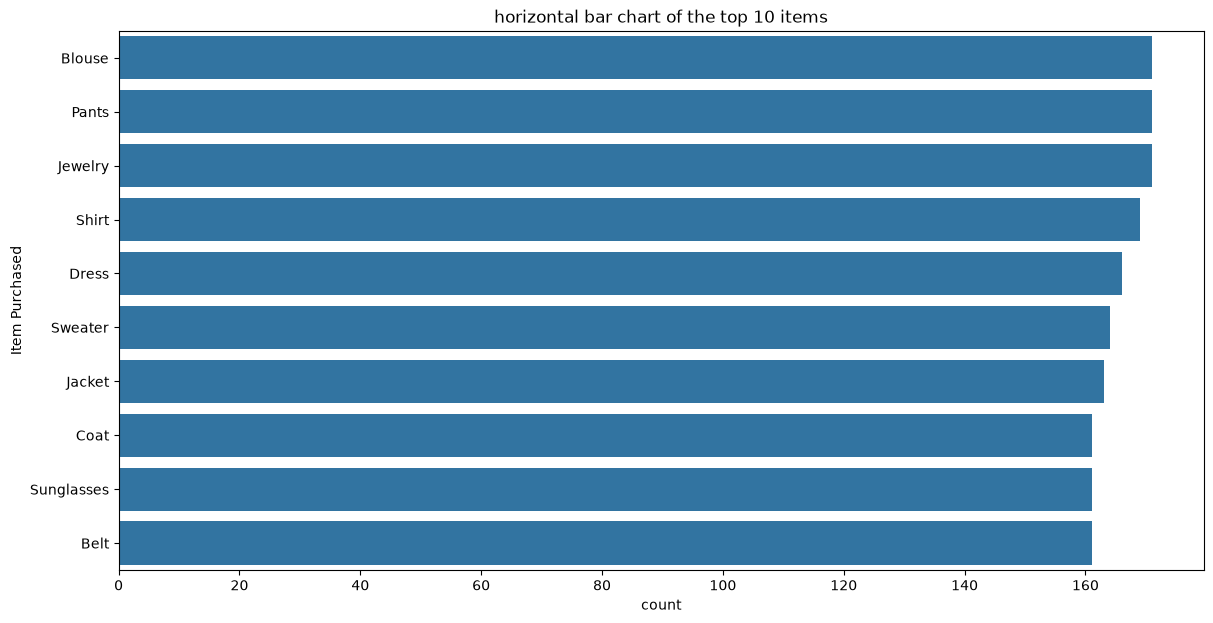

In [22]:
# TODO: plot a horizontal bar chart of the top 10 items with sns.barplot()
fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(
    data=top_item_all.head(10), 
    y = 'Item Purchased',
    x = 'count'
)
plt.title("horizontal bar chart of the top 10 items")
plt.show()

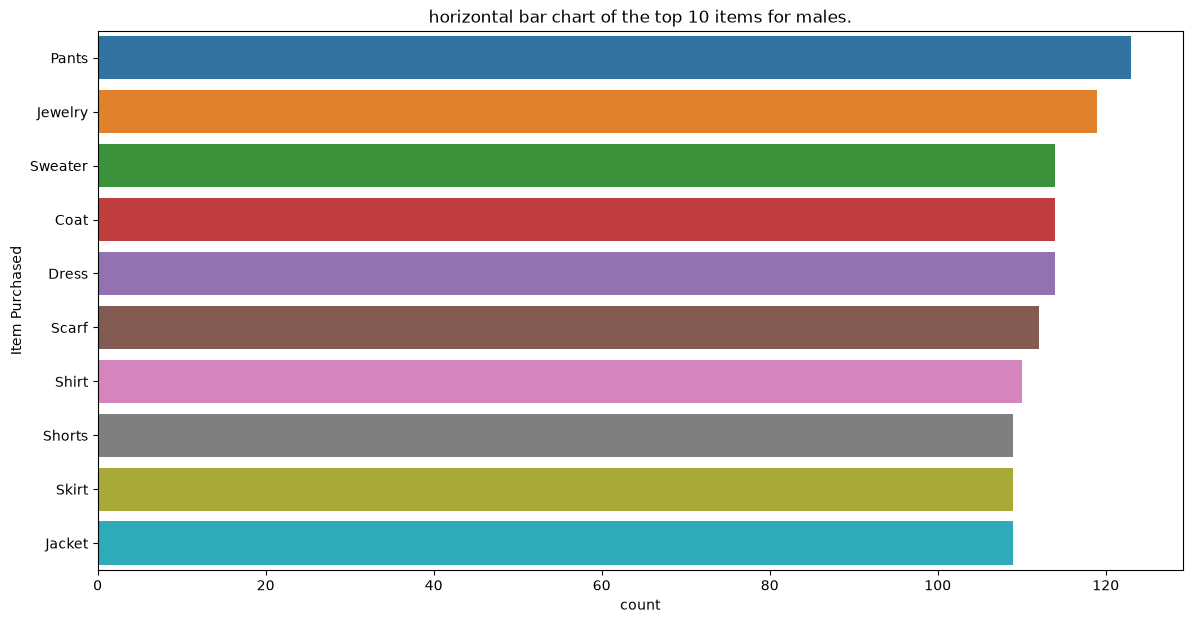

In [26]:
# TODO: plot a horizontal bar chart of the top 10 items for males with sns.barplot()
fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(
    data=top_item_male.head(10),
    y='Item Purchased',
    x = 'count',
    hue='Item Purchased'
)
plt.title("horizontal bar chart of the top 10 items for males.")
plt.show()

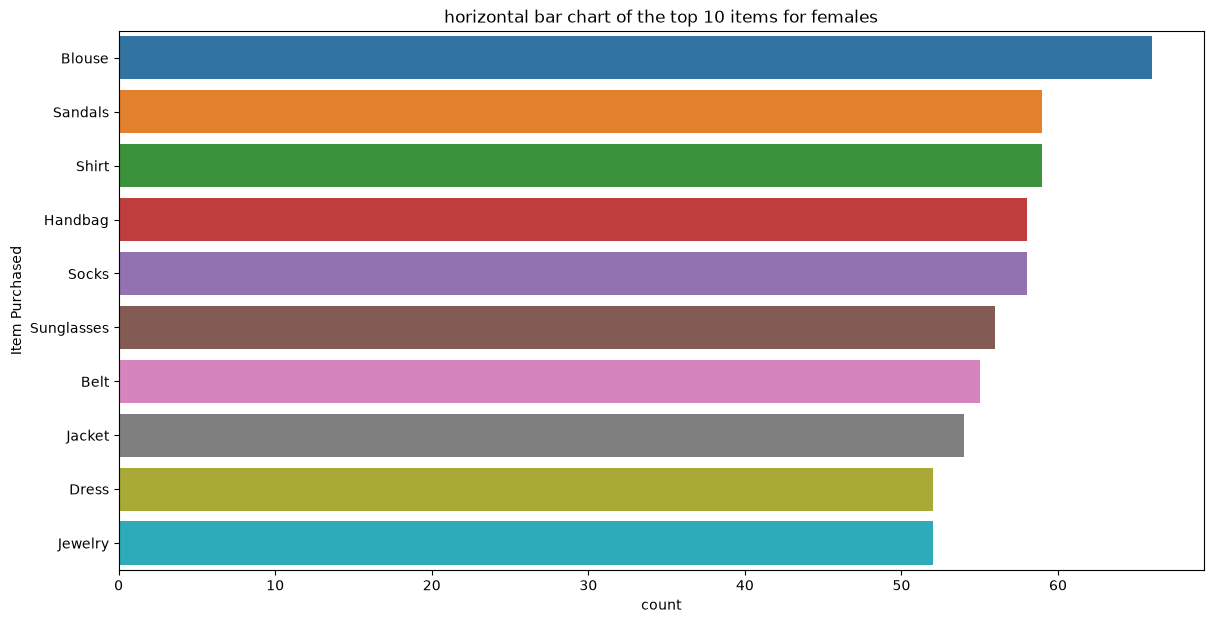

In [28]:
# TODO: plot a horizontal bar chart of the top 10 items for females with sns.barplot()
plt.subplots(figsize=(14, 7))
sns.barplot(
    data=top_item_female.head(10),
    y='Item Purchased', 
    x = 'count',
    hue='Item Purchased'
)
plt.title("horizontal bar chart of the top 10 items for females")
plt.show()

In [29]:
# TODO: count Size with value_counts() for all customers
df_clean['Size'].value_counts()

Size
M     1755
L     1053
S      663
XL     429
Name: count, dtype: int64

In [31]:
# TODO: count Size with value_counts() for male_df and female_df
size_male = male_df['Size'].value_counts()
size_female = female_df['Size'].value_counts()
print(f"size for male_df: {size_male}")
print("-"*50)
print(f"size for female_df: {size_female}")


size for male_df: Size
M     1165
L      716
S      476
XL     295
Name: count, dtype: int64
--------------------------------------------------
size for female_df: Size
M     590
L     337
S     187
XL    134
Name: count, dtype: int64


### **Category**

In [32]:
# TODO: count Category with value_counts().reset_index() for all customers
# ctg = ?
ctg = df_clean['Category'].value_counts().reset_index()
ctg

,Category,count
0,Clothing,1737
1,Accessories,1240
2,Footwear,599
3,Outerwear,324


In [34]:
# TODO: count Category with value_counts().reset_index() for male_df and female_df
ctg_male = male_df['Category'].value_counts().reset_index()
ctg_female = female_df['Category'].value_counts().reset_index()
print("category for male_df:")
print(ctg_male)
print("-"*50)
print(f"category for female_df:")
print(ctg_female)

category for male_df:
      Category  count
0     Clothing   1181
1  Accessories    848
2     Footwear    400
3    Outerwear    223
--------------------------------------------------
category for female_df:
      Category  count
0     Clothing    556
1  Accessories    392
2     Footwear    199
3    Outerwear    101


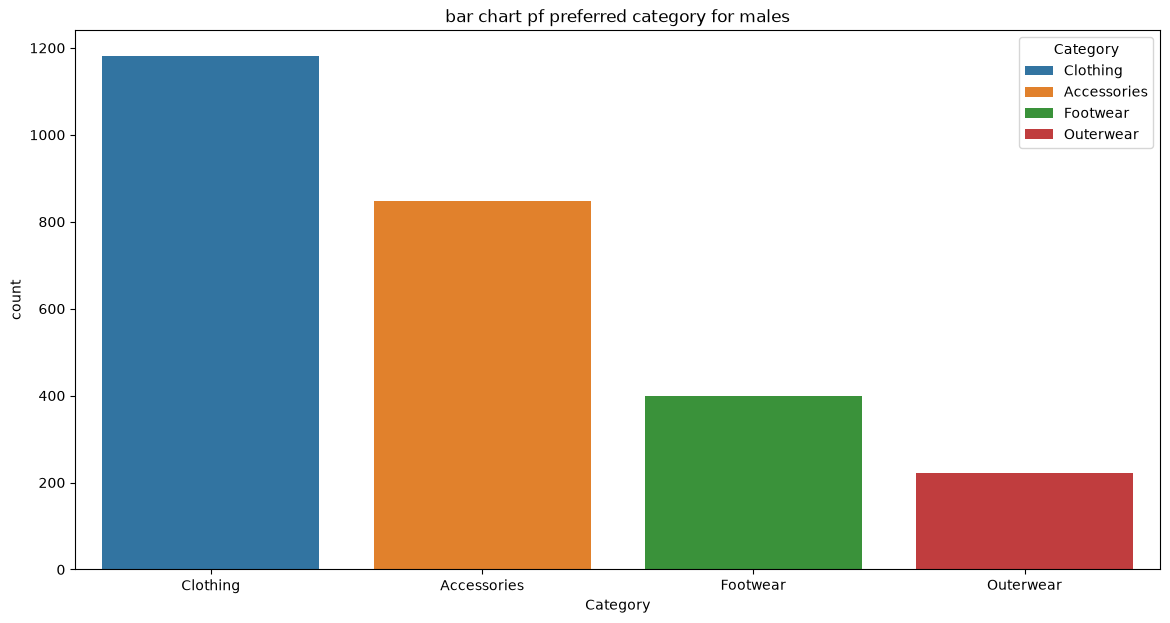

In [39]:
# TODO: plot a bar chart of preferred Category for males with sns.barplot()
plt.subplots(figsize=(14, 7))
sns.barplot(
    data= ctg_male,
    x = 'Category',
    y = 'count',
    hue='Category',
    legend=True
)
plt.title('bar chart pf preferred category for males')
plt.show()

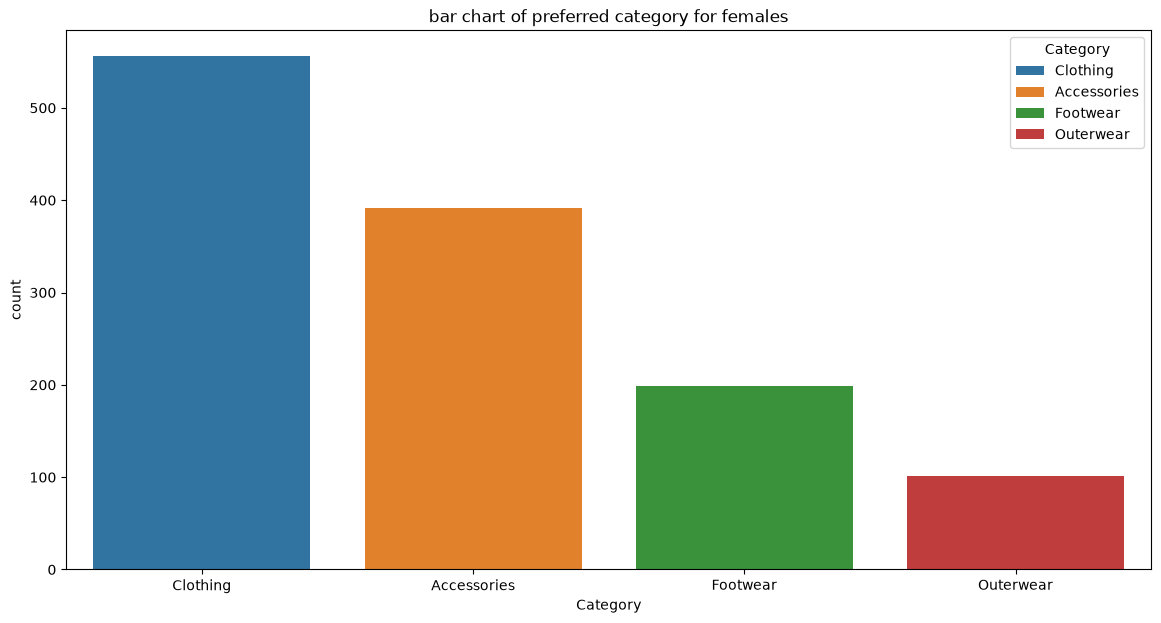

In [41]:
# TODO: plot a bar chart of preferred Category for females with sns.barplot()
plt.figure(figsize=(14, 7))
sns.barplot(
    data=ctg_female,
    x = 'Category',
    y = 'count',
    hue='Category', 
    legend=True
)
plt.title("bar chart of preferred category for females")
plt.show()

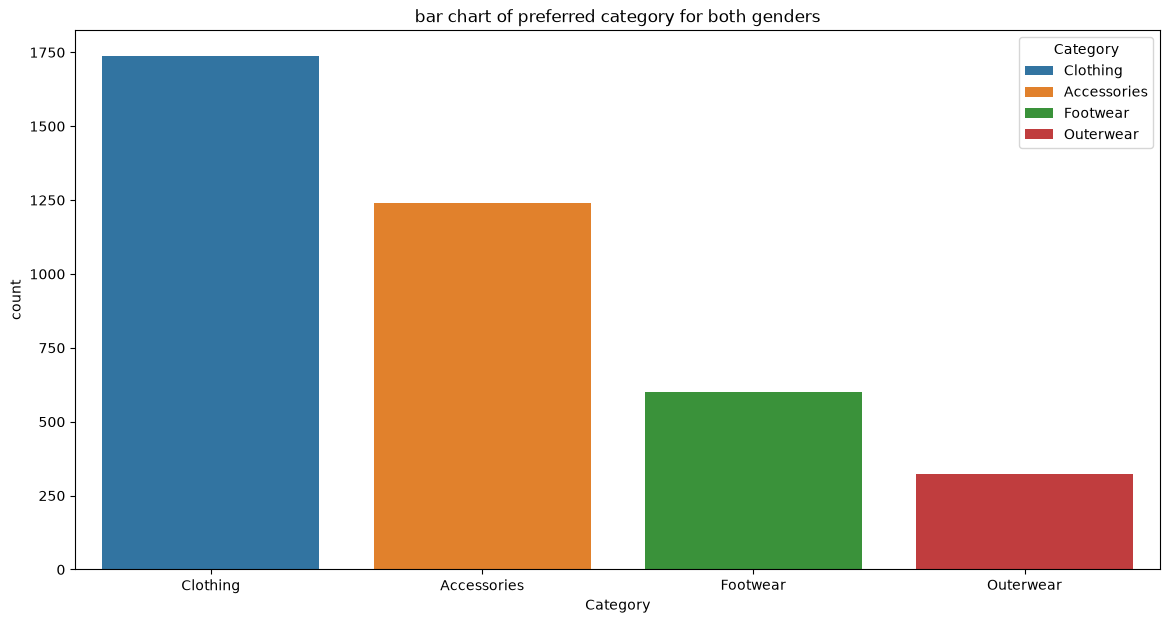

In [43]:
# TODO: plot a bar chart of preferred Category for both genders with sns.barplot()
plt.figure(figsize=(14, 7))
sns.barplot(
    data=ctg,
    x='Category',
    y='count',
    hue='Category',
    legend=True
)
plt.title("bar chart of preferred category for both genders")
plt.show()



In [52]:
# TODO: create waffle_data_m and waffle_data_f from Category value_counts()
waffle_data_m = dict(male_df['Category'].value_counts())
waffle_data_f = dict(female_df['Category'].value_counts())
waffle_data_f

{'Clothing': np.int64(556),
 'Accessories': np.int64(392),
 'Footwear': np.int64(199),
 'Outerwear': np.int64(101)}

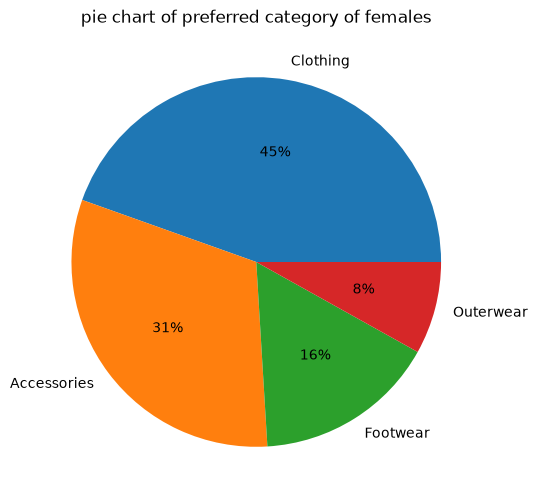

In [60]:
# TODO: plot a pie chart of preferred Category for females with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    x=waffle_data_f.values(),
    labels=waffle_data_f.keys(),
    autopct="%.0f%%"
)
plt.title("pie chart of preferred category of females")
plt.show()


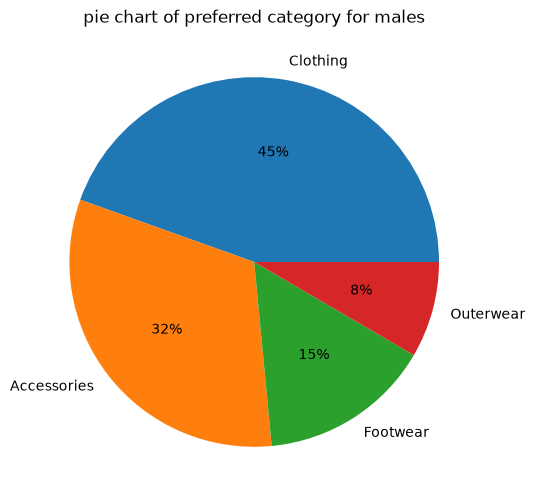

In [61]:
# TODO: plot a pie chart of preferred Category for males with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    x = waffle_data_m.values(),
    labels=waffle_data_m.keys(),
    autopct="%.0f%%"
)
plt.title("pie chart of preferred category for males")
plt.show()

### **Review ratings**

In [66]:
# TODO: filter female Clothing rows, then mean of Review Rating
# cr_f =
# avg_cr_f = ?
cr_f = female_df[female_df['Category'] == "Clothing"]
avg_cr_f = cr_f['Review Rating'].mean()


In [73]:
# TODO: filter male Clothing rows, then mean of Review Rating
# cr_m = ?
# avg_cr_m = ?
cr_m = male_df[male_df['Category'] == 'Clothing']
avg_cr_m = cr_m['Review Rating'].mean()


In [119]:
# avg_cr_m,avg_cr_f
print("mean of review ratting for female: ", avg_cr_f.round(4))
print('mean of Review Rating for male: ', avg_cr_m.round(4))

mean of review ratting for female:  3.7045
mean of Review Rating for male:  3.7319


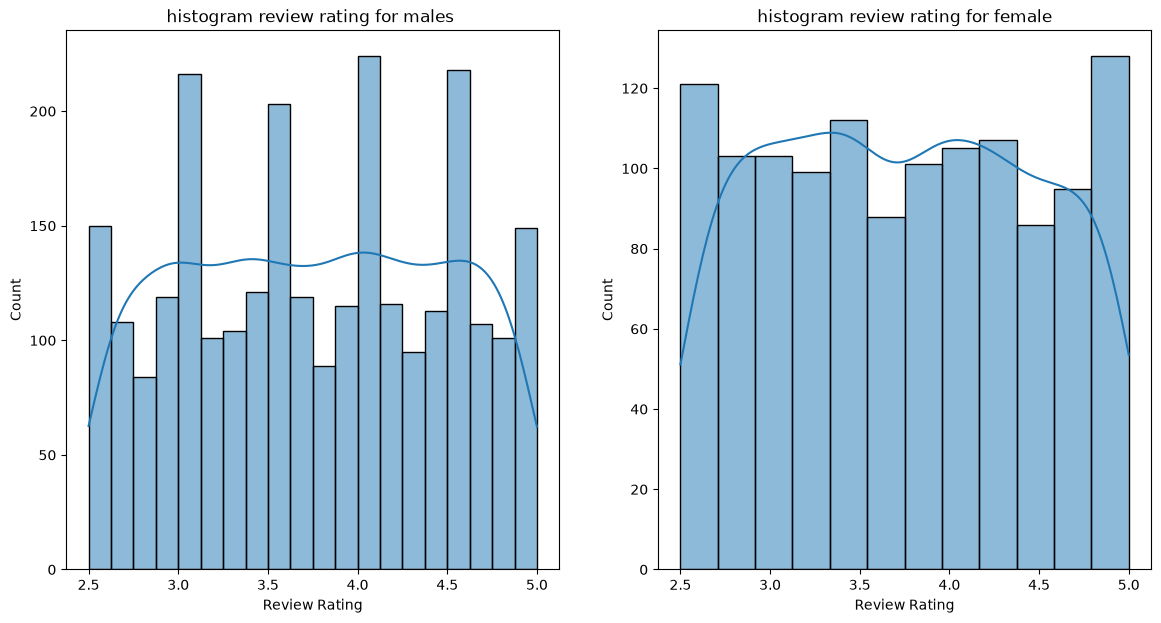

In [71]:
# TODO: plot Review Rating histograms for males and females with sns.histplot()
# males
fig, ax = plt.subplots(1, 2, figsize=(14, 7))
sns.histplot(
    data= male_df,
    x = 'Review Rating',
    kde=True,
    bins=20,
    ax= ax[0]
)
ax[0].set_title("histogram review rating for males ")


# females
# ?
sns.histplot(
    data = female_df,
    x = 'Review Rating',
    kde=True,
    ax=ax[1]
)
ax[1].set_title("histogram review rating for female")
plt.show()


In [74]:
# TODO: count Review Rating with value_counts() for male Clothing (cr_m)
cr_m['Review Rating'].value_counts()


Review Rating
3.7    61
3.4    59
2.7    55
2.9    55
4.0    52
4.2    52
3.9    52
3.3    49
3.0    49
4.9    48
4.1    48
3.5    48
3.1    46
4.7    46
4.6    46
3.6    46
4.8    46
2.6    45
4.3    45
4.4    43
3.2    41
2.8    41
3.8    39
4.5    36
2.5    17
5.0    16
Name: count, dtype: int64

### **Purchase Amount (USD)**

In [122]:
# TODO: sum Purchase Amount (USD) for males
m_tpa = male_df['Purchase Amount (USD)'].sum()
print(f"Total of Purchase Amount (USD) for males: {m_tpa}")

# # TODO: sum Purchase Amount (USD) for females
f_tpa = female_df['Purchase Amount (USD)'].sum()
print(f"Total of Purchase Amount (USD) for females: {f_tpa}")

Total of Purchase Amount (USD) for males: 157890
Total of Purchase Amount (USD) for females: 75191


Gender
Female     75191
Male      157890
Name: Purchase Amount (USD), dtype: int64


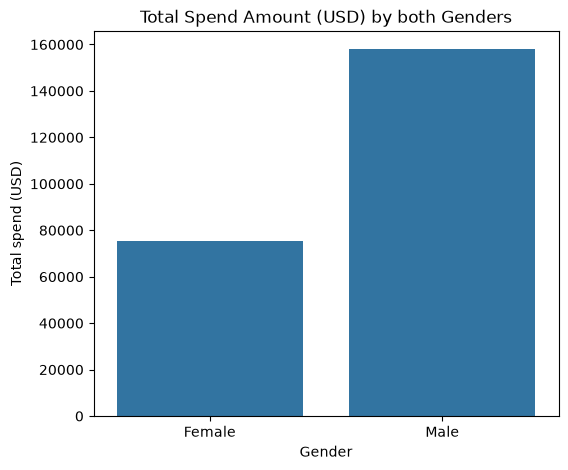

In [ ]:
# TODO: plot total spend by gender with sns.barplot()
spend_by_gender = df.groupby('Gender')['Purchase Amount (USD)'].sum()
plt.figure(figsize=(6, 5))
sns.barplot(
    spend_by_gender
)
plt.title("Total Spend Amount (USD) by both Genders")
plt.ylabel('Total spend (USD)')
plt.show()

In [124]:
# TODO: filter female_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_f = cr_f
ca_f = female_df[female_df['Category']=='Accessories']
cf_f = female_df[female_df['Category'] == 'Footwear']
co_f = female_df[female_df['Category'] == 'Outerwear']

In [134]:
# TODO: filter male_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_m = cr_m
ca_m = male_df[male_df['Category'] == 'Accessories']
cf_m = male_df[male_df['Category'] == 'Footwear']
co_m = male_df[male_df['Category'] == 'Outerwear']

In [126]:
# TODO: create pcu dict from Promo Code Used value_counts()
pcu = dict(df['Promo Code Used'].value_counts())
pcu

{'No': np.int64(2223), 'Yes': np.int64(1677)}

### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

<Axes: >

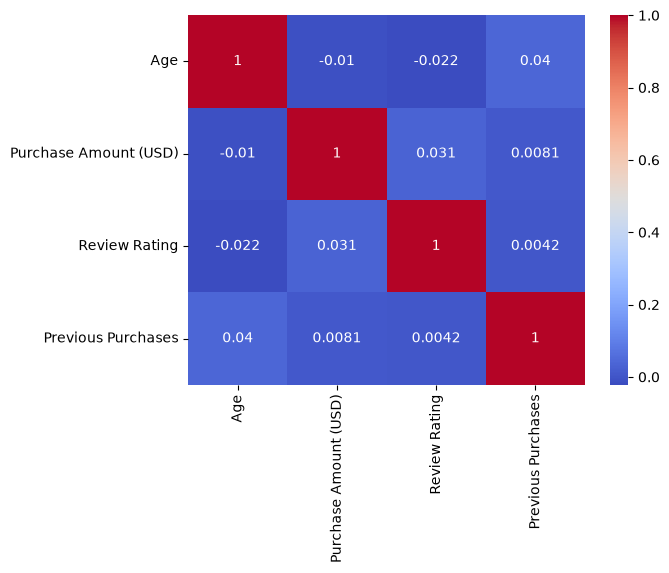

In [80]:
# TODO: compute correlation with df.corr(numeric_only=True), then plot a heatmap with sns.heatmap()
selected_cols = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
corr_selected_cols = df[selected_cols].corr()
sns.heatmap(corr_selected_cols, annot=True, cmap="coolwarm")

### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

In [136]:
# TODO: dummy variables for Gender, Size, and Category with pd.get_dummies()
df_processed = pd.get_dummies(df_clean, columns=['Gender', 'Size', 'Category'], dtype=float)
df_processed.head()

,Age,Item Purchased,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,...,Gender_Female,Gender_Male,Size_L,Size_M,Size_S,Size_XL,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear
0,55,Blouse,53,Kentucky,Gray,Winter,3.1,Yes,Credit Card,Express,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,19,Sweater,64,Maine,Maroon,Winter,3.1,Yes,Bank Transfer,Express,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,50,Jeans,73,Massachusetts,Maroon,Spring,3.1,Yes,Cash,Free Shipping,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,21,Sandals,90,Rhode Island,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,45,Blouse,49,Oregon,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [137]:
# TODO: use MinMaxScaler on Purchase Amount (USD) and StandardScaler on Age (keep original columns)
from sklearn.preprocessing import MinMaxScaler, StandardScaler

minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

df_processed['Amount_minmax'] = minmax_scaler.fit_transform(df_processed[['Purchase Amount (USD)']])
df_processed['Age_standard'] = standard_scaler.fit_transform(df_processed[['Age']])
df_processed[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()

,Purchase Amount (USD),Amount_minmax,Age,Age_standard
0,53,0.4125,55,0.718913
1,64,0.5500,19,-1.648629
2,73,0.6625,50,0.390088
3,90,0.8750,21,-1.517099
4,49,0.3625,45,0.061263


In [138]:
# TODO: use pd.cut() to bin Purchase Amount (USD) into Low / Medium / High
bins = [df_processed['Purchase Amount (USD)'].min(),
        df_processed['Purchase Amount (USD)'].quantile(0.33),
        df_processed['Purchase Amount (USD)'].quantile(0.66),
        df_processed['Purchase Amount (USD)'].max()]
labels = ['Low', 'Medium', 'High']
df_processed['Amount_bin'] = pd.cut(df_processed['Purchase Amount (USD)'], bins=bins, labels=labels, include_lowest=True)
df_processed['Amount_bin'].value_counts()

,count
Amount_bin,
Medium,1303
Low,1300
High,1297


### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
- Which items and categories are most common for males vs females?
- Do males and females spend a similar total amount?
- Is Review Rating similar across genders?
- How often is a promo code used?

# TODO: write insights
-   Khách hàng nam mua hàng nhiều hơn đáng kể so với khách hàng nữ về số lượng sản phẩm.
-   Các danh mục "Clothing" và "Accessories" là những danh mục phổ biến nhất đối với cả nam và nữ.
-   Điểm đánh giá trung bình không có sự khác biệt lớn giữa nam và nữ.
-   Mặt hàng "Blouse" và "Pants" là những mặt hàng được mua nhiều nhất nói chung.  
-   Việc sử dụng mã khuyến mãi là khá phổ biến, với 1677 giao dịch sử dụng mã khuyến mãi so với 2223 không sử dụng.

Caveat: correlation is not causation.